# Naive Bayes

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [4]:
## Load the dataset
X,y=load_iris(return_X_y=True) ## Learn this
X[:5], y[:5]

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2]]),
 array([0, 0, 0, 0, 0]))

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

We will use gaussian naive bayes for this training because the features are continuous. We can check if they are normally distributed.

In [6]:
## gaussian naive bayes
from sklearn.naive_bayes import GaussianNB

In [7]:
gnb=GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

In [13]:
y_pred=gnb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
print(accuracy)
print(cm)
print(classification_report(y_test,y_pred))


1.0
[[16  0  0]
 [ 0 18  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        11

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



A perfect prediction.

In [30]:
## Practice with tips dataset from seaborn
## Take time as the output feature

import seaborn as sns 
tips_df=sns.load_dataset('tips')
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [31]:
X_data=tips_df[['total_bill','tip','sex','smoker','day','size']]
y_data=tips_df['time']

In [32]:
X_data.head()

,total_bill,tip,sex,smoker,day,size
0,16.99,1.01,Female,No,Sun,2
1,10.34,1.66,Male,No,Sun,3
2,21.01,3.50,Male,No,Sun,3
3,23.68,3.31,Male,No,Sun,2
4,24.59,3.61,Female,No,Sun,4


In [33]:
X_data.day.unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

In [34]:
y_data.head()

0    Dinner
1    Dinner
2    Dinner
3    Dinner
4    Dinner
Name: time, dtype: category
Categories (2, object): ['Lunch', 'Dinner']

In [35]:
y_data.value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [36]:
## lets split before performing feature-encoding
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_data,y_data,test_size=0.25,random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((183, 6), (61, 6), (183,), (61,))

In [37]:
X_train.head()

,total_bill,tip,sex,smoker,day,size
115,17.31,3.50,Female,No,Sun,2
181,23.33,5.65,Male,Yes,Sun,2
225,16.27,2.50,Female,Yes,Fri,2
68,20.23,2.01,Male,No,Sat,2
104,20.92,4.08,Female,No,Sat,2


In [38]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le1=LabelEncoder()
y_train=le1.fit_transform(y_train)
y_test=le1.transform(y_test)

In [39]:
## We will use one-hot-encoding for the independent features

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(
    X_train[['sex', 'smoker', 'day']]
)

In [40]:
import pandas as pd
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['sex','smoker','day']),
    index=X_train.index
)

In [41]:
X_train = pd.concat(
    [X_train.drop(['sex','smoker','day'], axis=1), encoded_df],
    axis=1
)

X_train.head()

,total_bill,tip,size,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur
115,17.31,3.50,2,0.0,0.0,0.0,1.0,0.0
181,23.33,5.65,2,1.0,1.0,0.0,1.0,0.0
225,16.27,2.50,2,0.0,1.0,0.0,0.0,0.0
68,20.23,2.01,2,1.0,0.0,1.0,0.0,0.0
104,20.92,4.08,2,0.0,0.0,1.0,0.0,0.0


In [44]:
## Lets do the same for Test

# Transform test data using the fitted encoder
encoded_test = encoder.transform(
    X_test[['sex', 'smoker', 'day']]
)

# Convert to DataFrame
encoded_df_test = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(['sex','smoker','day']),
    index=X_test.index
)

# Merge back with remaining columns
X_test = pd.concat(
    [X_test.drop(['sex','smoker','day'], axis=1), encoded_df_test],
    axis=1
)

X_test.head()

,total_bill,tip,size,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur
24,19.82,3.18,2,1.0,0.0,1.0,0.0,0.0
6,8.77,2.00,2,1.0,0.0,0.0,1.0,0.0
153,24.55,2.00,4,1.0,0.0,0.0,1.0,0.0
211,25.89,5.16,4,1.0,1.0,1.0,0.0,0.0
198,13.00,2.00,2,0.0,1.0,0.0,0.0,1.0


In [45]:
## gaussian naive bayes
from sklearn.naive_bayes import GaussianNB

gnb2=GaussianNB()
gnb2.fit(X_train,y_train)


GaussianNB()

In [46]:
y_pred=gnb2.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
print(accuracy)
print(cm)
print(classification_report(y_test,y_pred))

0.9508196721311475
[[41  3]
 [ 0 17]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        44
           1       0.85      1.00      0.92        17

    accuracy                           0.95        61
   macro avg       0.93      0.97      0.94        61
weighted avg       0.96      0.95      0.95        61



it has a very good performance

In [47]:
## Lets check teh distribution of the continuous features (tips and total bill)

import matplotlib.pyplot as plt
import seaborn as sns

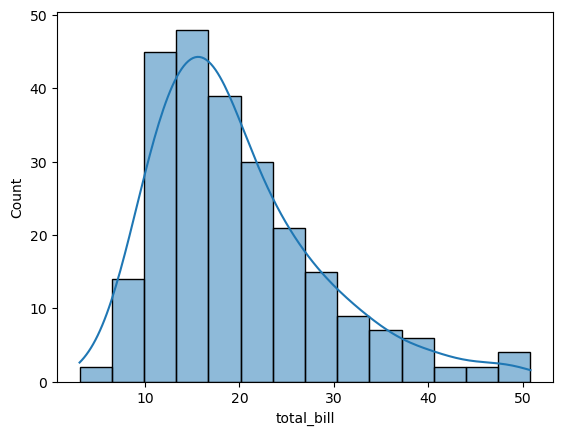

In [50]:
sns.histplot(data=tips_df, x='total_bill', kde=True)
plt.show()

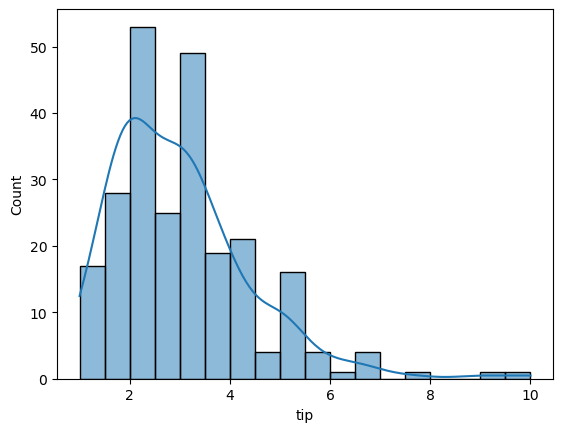

In [51]:
sns.histplot(data=tips_df, x='tip',kde=True)
plt.show()